## Plots and spearman correlation values shown on the poster for light chains are written as a code here ##

In [ ]:
#loading the dictionary from another file for consensus sequences
import json

with open("consensus_dict.json", "r") as f:
    consensus_dict = json.load(f)

print(consensus_dict)

#loading clean_antigen_map from another file
with open("cleaned_antigen_map", "r") as f:
    cleaned_antigen_map = json.load(f)

print(cleaned_antigen_map)

#defininf hamming distance
def hamming_dist(seq1, seq2):
    return sum(a != b for a, b in zip(seq1, seq2))

#defining the color scheme 
color_map = {
    'homo sapiens': 'red',
    'SARS-CoV-2': 'blue',
    'both': 'purple'
}

kappa_consensus = {k: v for k, v in consensus_dict.items() if 'k' in k.lower()}
lambda_consensus = {k: v for k, v in consensus_dict.items() if 'l' in k.lower()}

max_len = max(len(seq) for seq in consensus_dict.values())

#padding the consensus sequences to the same lenght by adding '_' as an extention 
def pad(seq, length):
    return seq + "_" * (length - len(seq))

#saving padded consensus sequences
kappa_consensus_padded = {k: pad(v, max_len) for k, v in kappa_consensus.items()}
lambda_consensus_padded = {k: pad(v, max_len) for k, v in lambda_consensus.items()}

{'IGKV1': 'MD_K___IHNHHK___________________DIQMTQSPSSLSASVGDRVTITCRASQ___Y_______L_WYQQKPGKAPKLLIY_AST_L_SGVPSRFSSRATLTGSGSGTDFTLTISSLQPEDFATYYCQQ__________TFG_GTKVEIKR_T_VAAPSVFIFS__PPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGECS__________QLIMVTNKAIASQ', 'IGLV1': 'MGILPSPGM_______L_L_____G__S_QSVLTQPPS_S__PGQRVTISC_GS_SNLY_NIG____V_WYQQQLPG_APKLLIY____RPSGVPDRFSGSKSGSSTSASLAI_GLQ_EDEADYYC___D_SL_____VFGGGTK_TVL_TKLTVLGQPKAAPSVTLFPPSSEELQANKATLVCLISDFYPGAVTVAWKADSSPVKAGSVETTTPSKQSNNKYAASSYLSLTPEQWKSHRSYSCQVTHEGSSSTVEKTVAPTECSAAENLYFQGS', 'IGKV3': 'PNITNLCP____________L_________NCVAEIV_TQSP_TLSLSPGERATLSCRASQSV___DLCFTNVYA_______LAWYQQKPGQAPRLLIY_AS_RATGIP_RFSGSGSGTDFTLTIS_LEPEDFAVYYCQQ____PS____TFG_GTKVQ_EIKRT___PTVSIFPPSSEQLTSGGASVVCFTVAAPSVFIFPPSDEQLKSGTASVVCLLNNFYPREAKVQWKVDNALQSGNSQESVTEQDSKDSTYSLSSTLTLSKADYEKHKVYACEVTHQGLSSPVTKSFNRGEC____Q______TNGVGY_______LS_A_________C__T__GL____________H', 'IGKV6': 'DIV_TQ___F_S_S____V_ITC_ASQ_

### here the hierarchical clustering of the light subclass gene families is executed based on their consensus sequences. furthermore, the annotations below the graphs visually show which antigen species it targets - whether it is SARS-CoV2, *homo sapiens* or both ###

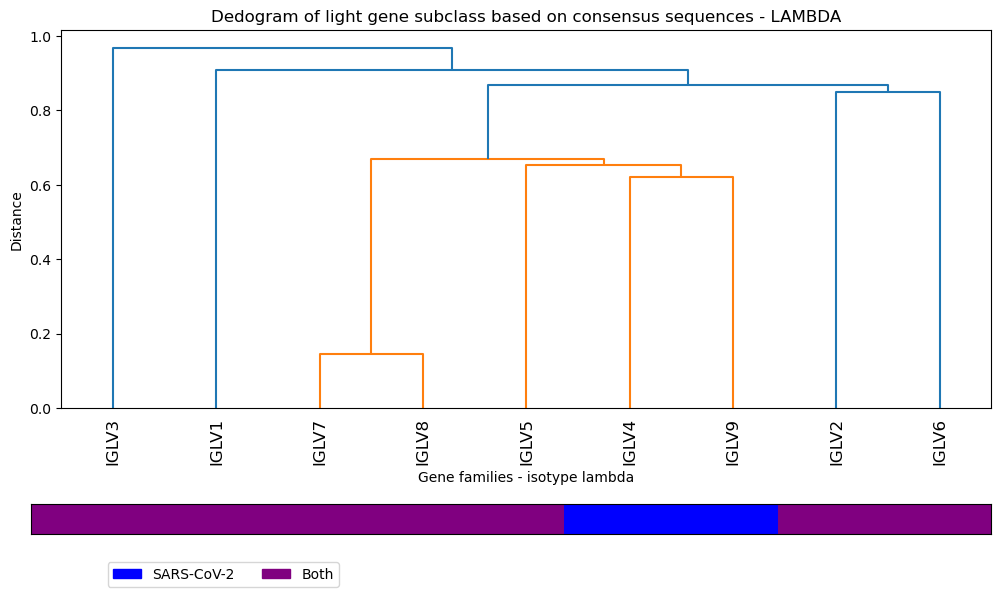

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.patches as mpatches

#function for clustering of lambda isotype

def cluster_and_plot_lambda(consensus_dict, cleaned_antigen_map, color_map, title_prefix=""):
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])

    max_dist = dist_matrix.max()
    if max_dist > 0:
        dist_matrix = dist_matrix / max_dist

    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.subplots_adjust(bottom=0.25)

    dendro = dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title("Dedogram of light gene subclass based on consensus sequences - LAMBDA")
    ax.set_ylabel("Distance")
    ax.set_xlabel("Gene families - isotype lambda")

    label_order = dendro["ivl"]
    species_list = [cleaned_antigen_map.get(label, "") for label in label_order]
    color_names = [color_map.get(species, "gray") for species in species_list]
    rgb_colors = [to_rgb(c) for c in color_names]

    color_ax = fig.add_axes([0.1, 0.04, 0.8, 0.05])
    color_ax.imshow([rgb_colors], aspect="auto")
    color_ax.set_xticks([])
    color_ax.set_yticks([])
 
    legend_patches = [
        mpatches.Patch(color=color_map["SARS-CoV-2"], label="SARS-CoV-2"),
        mpatches.Patch(color=color_map["both"], label="Both")
    ]
    plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.2, -2), ncol=3)

    plt.show()


cluster_and_plot_lambda(lambda_consensus_padded, cleaned_antigen_map, color_map, title_prefix="LAMBDA")


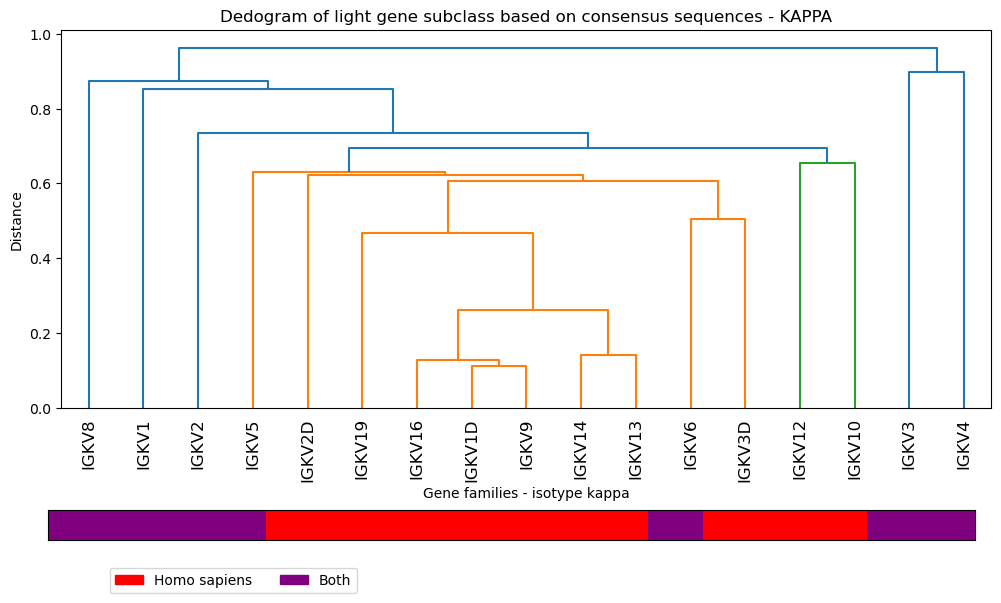

In [ ]:
#function for clustering of kappa isotype

def cluster_and_plot_kappa(consensus_dict, cleaned_antigen_map, color_map, title_prefix=""):
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())

    dist_matrix = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    max_dist = dist_matrix.max()
    if max_dist > 0:
        dist_matrix = dist_matrix / max_dist
    linkage_matrix = linkage(squareform(dist_matrix), method="average")

    fig, ax = plt.subplots(figsize=(12, 6))
    plt.subplots_adjust(bottom=0.25)

    dendro = dendrogram(linkage_matrix, labels=labels, leaf_rotation=90, ax=ax)
    ax.set_title("Dedogram of light gene subclass based on consensus sequences - KAPPA")
    ax.set_ylabel("Distance")
    ax.set_xlabel("Gene families - isotype kappa")

    label_order = dendro["ivl"]
    species_list = [cleaned_antigen_map.get(label, "") for label in label_order]
    color_names = [color_map.get(species, "gray") for species in species_list]
    rgb_colors = [to_rgb(c) for c in color_names]

    color_ax = fig.add_axes([0.1, 0.03, 0.8, 0.05])
    color_ax.imshow([rgb_colors], aspect="0.55")
    color_ax.set_xticks([])
    color_ax.set_yticks([])

 
    legend_patches = [
        mpatches.Patch(color=color_map["homo sapiens"], label="Homo sapiens"),
        mpatches.Patch(color=color_map["both"], label="Both")
    ]
    plt.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.2, -2), ncol=3)

    plt.show()


cluster_and_plot_kappa(kappa_consensus_padded, cleaned_antigen_map, color_map, title_prefix="KAPPA")

### spearman correlation and the significance of the test for both kappa and lambda isotypes are shown below ###

In [11]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import mantel
from collections import defaultdict
from itertools import combinations
import random

np.random.seed(100)
random.seed(100)

#function for jaccard distance between two sets (1 − (number of shared items / total unique items))
def jaccard_distance(set1, set2):
    intersection = len(set1 & set2)
    union = len(set1 | set2)
    return 1 - intersection / union if union > 0 else 1.0

#making map that either contains only kappa or lambda isotypes in it for clean separation
kappa_antigen_map = {k: v for k, v in cleaned_antigen_map.items() if k in kappa_consensus_padded}
lambda_antigen_map = {k: v for k, v in cleaned_antigen_map.items() if k in lambda_consensus_padded}

#function to run mantel test
def run_mantel(consensus_dict, antigen_map, label=""):

    #defining the gene family names as labels and consensus sequences as sequences
    labels = list(consensus_dict.keys())
    sequences = list(consensus_dict.values())
    
    #creating distance matrix based on hamming distances between consensus sequences
    dist_consensus = np.array([[hamming_dist(s1, s2) for s2 in sequences] for s1 in sequences])
    dm1 = DistanceMatrix(squareform(dist_consensus), ids=labels)
    
    #
    antigen_sets = [set(map(str.lower, antigen_map.get(l, set()))) for l in labels]
    
    #creating distance matrix based on jaccard distances between antigen_set that target antigen species
    dist_antigen = np.zeros((len(labels), len(labels)))
    for i, j in combinations(range(len(labels)), 2):
        d = jaccard_distance(antigen_sets[i], antigen_sets[j])
        dist_antigen[i, j] = dist_antigen[j, i] = d
    dm2 = DistanceMatrix(dist_antigen, ids=labels)

    #matrices are matches based on the labels
    common = list(set(dm1.ids) & set(dm2.ids))
    dm1_filtered = dm1.filter(common)
    dm2_filtered = dm2.filter(common)

    #running mantel test with spearman correlation 
    r_val, p_val, _ = mantel(dm1_filtered, dm2_filtered, method='spearman', permutations=999)

    print(f"\nMantel Test Result ({label}):")
    print(f"Spearman correlation between distance matrices: r = {r_val:.4f}")
    print(f"P-value: {p_val:.4f}")

run_mantel(kappa_consensus_padded, kappa_antigen_map, label="Kappa light chains")
run_mantel(lambda_consensus_padded, lambda_antigen_map, label="Lambda light chains")



Mantel Test Result (Kappa light chains):
Spearman correlation between distance matrices: r = 0.3557
P-value: 0.0020

Mantel Test Result (Lambda light chains):
Spearman correlation between distance matrices: r = -0.1948
P-value: 0.5740


to note is: 

- mantel test is a permutation-based test that estimates the correlation between two distance matrices.
- the p-value is therefore approximate and may vary slightly, and may look different on the poster

